<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Data_Analysis_Crash_Course_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis Crash Course: From Hypothesis to Prediction

### নোটবুক পরিচিতি (Metadata)

* **Aim:** স্ট্যাটিস্টিক্যাল মেথডগুলো (t-test, ANOVA, Chi-square, Regression) ব্যবহার করে ডেটা বিশ্লেষণ এবং তার সঠিক ব্যাখ্যা প্রদান।
* **Concept:** আমরা দেখব কীভাবে বিভিন্ন ভ্যারিয়েবলের মধ্যে সম্পর্ক খুঁজে বের করতে হয় এবং সেই তথ্যের ভিত্তিতে ভবিষ্যৎ প্রেডিকশন করা যায়।
* **Key Skills:** Hypothesis Testing, ANOVA Post-hoc, Categorical Analysis, এবং Linear Modeling।

---

## ১. এনভায়রনমেন্ট সেটআপ (Environment Setup)

In [1]:
# প্রয়োজনীয় লাইব্রেরি লোড করা
install.packages('gapminder')
install.packages('plyr')
install.packages('ggpubr')
install.packages('tidyverse')
install.packages('palmerpenguins')

library(gapminder)
library(plyr)
library(ggpubr)
library(tidyverse)
library(palmerpenguins)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2


Attaching package: ‘ggpubr’


The following object is masked from ‘package:plyr’:

    mutate


── Attaching core tidyve

## ২. হাইপোথিসিস টেস্টিং: Two-Sample t-Test

**উদ্দেশ্য:** আমেরিকা এবং এশিয়া মহাদেশের গড় আয়ুর মধ্যে কোনো বাস্তব পার্থক্য আছে কি না তা দেখা।

### ভিজ্যুয়ালাইজেশন ও টেস্ট

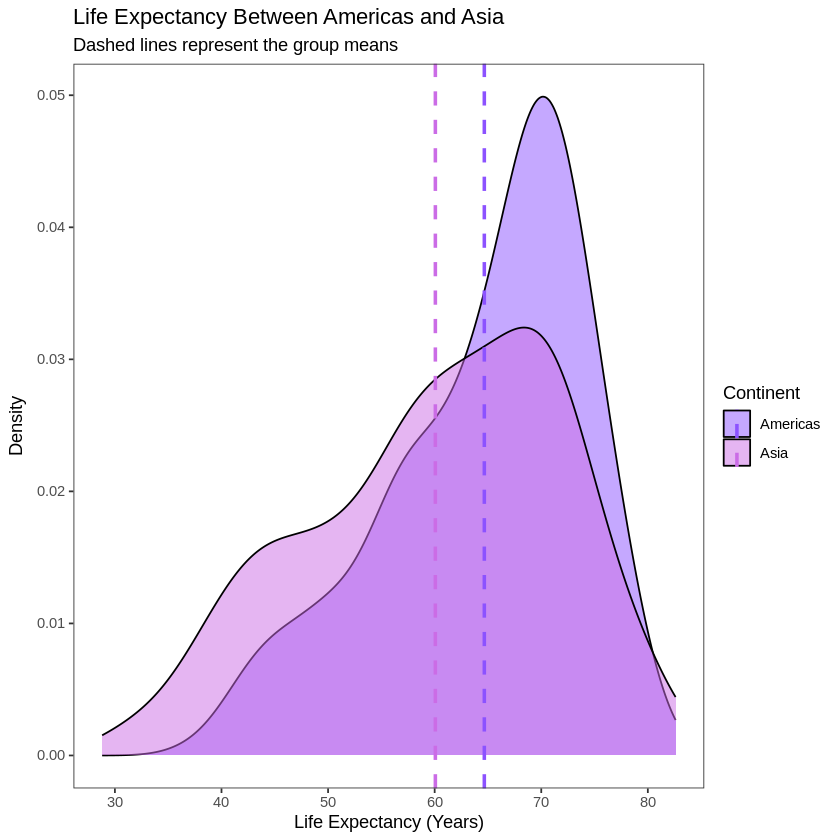

In [2]:
# ১. ডেটা প্রসেসিং এবং গড় (Mean) ক্যালকুলেশন একসাথেই করা
df <- gapminder %>%
  filter(continent %in% c("Americas", "Asia")) %>%
  select(continent, lifeExp)

mu <- df %>%
  group_by(continent) %>%
  summarise(grp.mean = mean(lifeExp, na.rm = TRUE))

# ২. ডেনসিটি প্লট তৈরি
df %>%
  ggplot(aes(x = lifeExp, fill = continent)) +
  geom_density(alpha = 0.5) +
  # গড় লাইনের জন্য ড্যাশ লাইন যোগ করা
  geom_vline(data = mu, aes(xintercept = grp.mean, color = continent),
             linetype = "dashed", linewidth = 1) +
  # কাস্টম কালার সেট করা
  scale_fill_manual(values = c("Americas" = "#8C52FF", "Asia" = "#CB6CE6")) +
  scale_color_manual(values = c("Americas" = "#8C52FF", "Asia" = "#CB6CE6")) +
  labs(
    title = "Life Expectancy Between Americas and Asia",
    subtitle = "Dashed lines represent the group means",
    x = "Life Expectancy (Years)",
    y = "Density",
    fill = "Continent",
    color = "Continent"
  ) +
  theme_test()

In [3]:
# t-Test সম্পাদন
gapminder %>%
  filter(continent %in% c("Americas", "Asia")) %>%
  t.test(lifeExp ~ continent, data = ., alternative = "two.sided")


	Welch Two Sample t-test

data:  lifeExp by continent
t = 5.713, df = 692.94, p-value = 1.648e-08
alternative hypothesis: true difference in means between group Americas and group Asia is not equal to 0
95 percent confidence interval:
 3.015071 6.172596
sample estimates:
mean in group Americas     mean in group Asia 
              64.65874               60.06490 


> **ইন্টারপ্রিটেশন:** যদি p-value < 0.05 হয়, তবে প্রমাণিত হয় যে এই দুই মহাদেশের মানুষের গড় আয়ুর পার্থক্যটি স্ট্যাটিস্টিক্যালি সিগনিফিকেন্ট।

## ৩. Analysis of Variance (ANOVA)

যখন আমাদের ২টির বেশি গ্রুপ থাকে (যেমন: পেঙ্গুইনের ৩টি প্রজাতি), তখন আমরা ANOVA ব্যবহার করি।

### পেঙ্গুইনের প্রজাতির ভিত্তিতে ফ্লিপার লেন্থ তুলনা


In [4]:
# ANOVA টেস্ট
anova_res <- penguins %>%
  aov(flipper_length_mm ~ species, data = .)
summary(anova_res)


             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [5]:
# Tukey-HSD: কোন প্রজাতি কার থেকে আলাদা তা দেখা
TukeyHSD(anova_res)


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = .)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


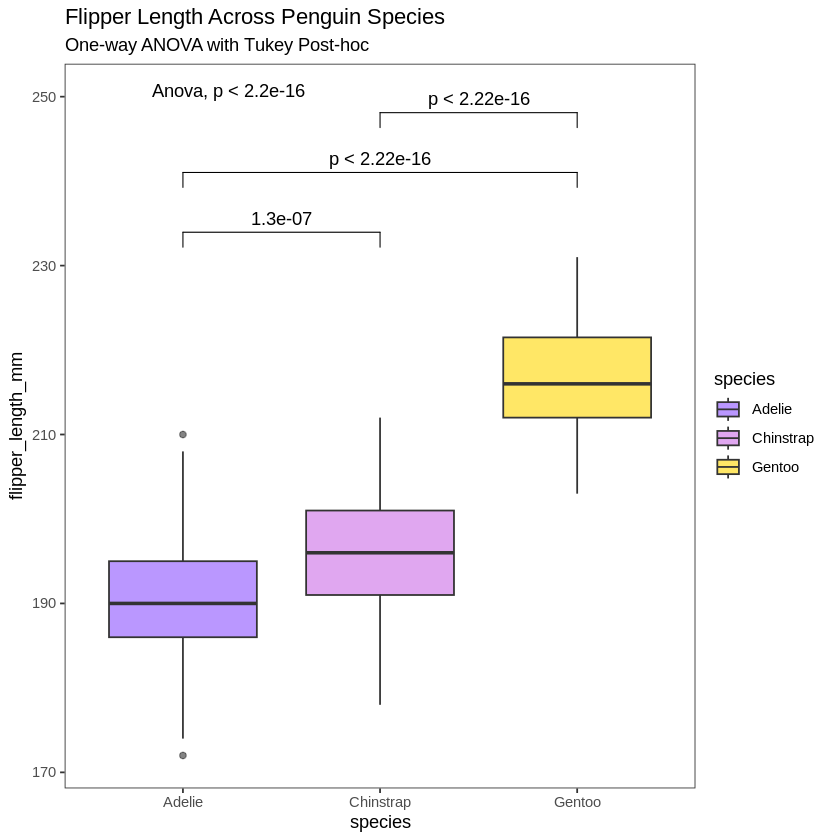

In [6]:
# বক্সপ্লট ভিজ্যুয়ালাইজেশন (ANOVA ও t-test লেবেল সহ)
penguins %>%
  drop_na() %>%
  ggplot(aes(species, flipper_length_mm, fill = species)) +
  geom_boxplot(alpha = 0.6) +
  stat_compare_means(method = "anova", label.y = 250) +
  stat_compare_means(comparisons = list(c("Adelie", "Chinstrap"), c("Adelie", "Gentoo"), c("Chinstrap", "Gentoo")), method = "t.test") +
  labs(title = "Flipper Length Across Penguin Species", subtitle = "One-way ANOVA with Tukey Post-hoc") +
  scale_fill_manual(values = c("#8C52FF", "#CB6CE6", "#FFD700")) +
  theme_test()

---

## ৪. Chi-Squared Tests (ক্যাটাগরিক্যাল ডেটা)

এটি ব্যবহৃত হয় যখন আমরা ক্যাটাগরিক্যাল ডেটার (যেমন: ফুলের আকার) ডিস্ট্রিবিউশন বা সম্পর্ক দেখতে চাই।

### i) Goodness of Fit (ডিস্ট্রিবিউশন চেক)


In [7]:

flower <- iris %>%
  mutate(size = cut(Sepal.Length, breaks = 3, labels = c("Small", "Medium", "Large"))) %>%
  select(Species, size)

flower %>% select(size) %>% table() %>% chisq.test()



	Chi-squared test for given probabilities

data:  .
X-squared = 28.44, df = 2, p-value = 6.673e-07


### ii) Test of Independence (প্রজাতি ও আকারের সম্পর্ক)

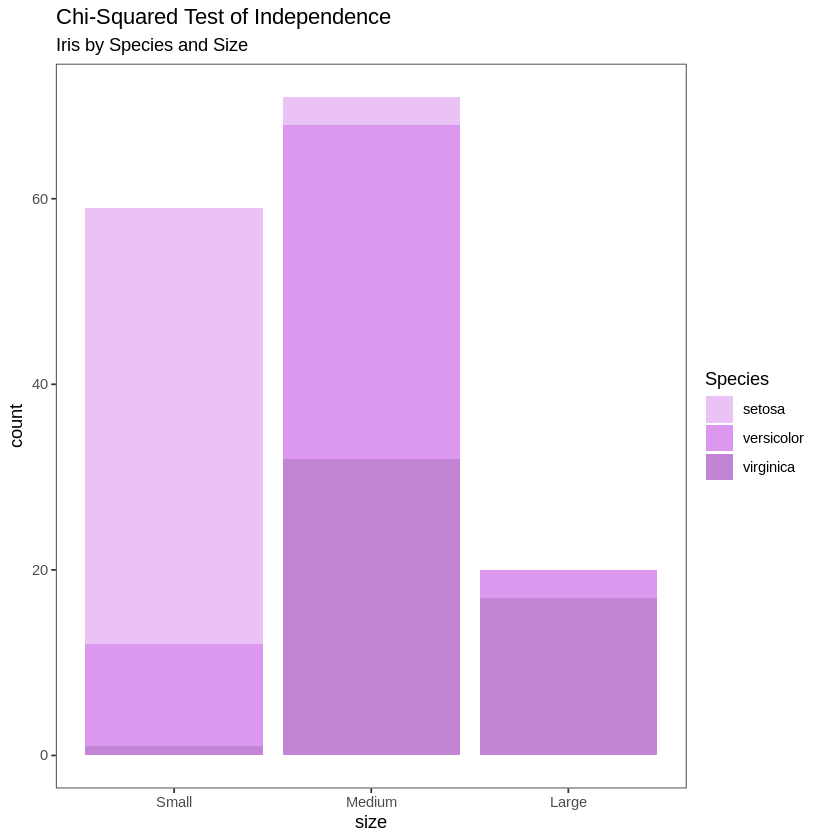

In [8]:
# ভিজ্যুয়ালাইজেশন: স্ট্যাকড বার চার্ট
flower %>%
  ggplot(aes(size, fill = Species)) +
  geom_bar(alpha = 0.7) +
  labs(title = "Chi-Squared Test of Independence", subtitle = "Iris by Species and Size") +
  scale_fill_manual(values = c("setosa" = "#E2A7F1", "versicolor" = "#CB6CE6", "virginica" = "#A751C2")) +
  theme_test()

In [9]:
# Chi-squared Test
flower %>% table() %>% chisq.test()



	Pearson's Chi-squared test

data:  .
X-squared = 111.63, df = 4, p-value < 2.2e-16


> **ইন্টারপ্রিটেশন:** p-value < 0.05 হলে বোঝা যায় যে প্রজাতির ওপর ভিত্তি করে ফুলের সাইজ ভিন্ন ভিন্ন হয় (তারা স্বাধীন নয়)।

---

## ৫. Simple Linear Regression & Prediction

গাড়ির স্পিড এবং ব্রেকিং ডিসট্যান্সের সম্পর্ক নির্ণয় এবং ভবিষ্যৎ অনুমান।

### মডেল তৈরি ও ভিজ্যুয়ালাইজেশন

In [10]:
# লিনিয়ার মডেল তৈরি
model <- lm(dist ~ speed, data = cars)
summary(model)


Call:
lm(formula = dist ~ speed, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.069  -9.525  -2.272   9.215  43.201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17.5791     6.7584  -2.601   0.0123 *  
speed         3.9324     0.4155   9.464 1.49e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.38 on 48 degrees of freedom
Multiple R-squared:  0.6511,	Adjusted R-squared:  0.6438 
F-statistic: 89.57 on 1 and 48 DF,  p-value: 1.49e-12


`geom_smooth()` using formula = 'y ~ x'


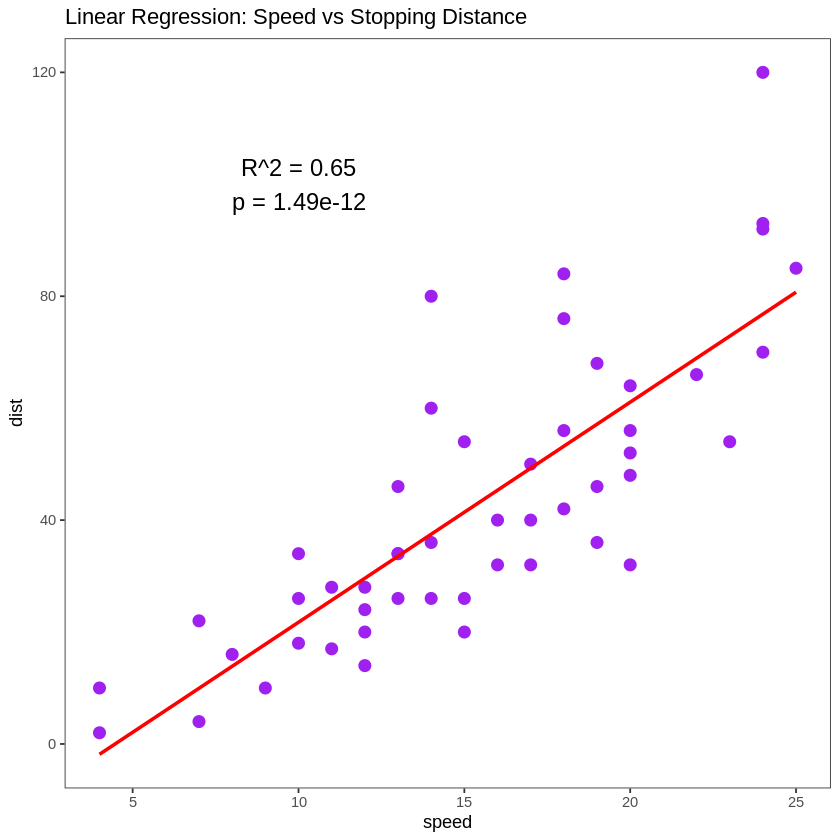

In [11]:
# রিগ্রেশন প্লট
ggplot(cars, aes(speed, dist)) +
  geom_point(size = 3, color = "purple") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  annotate("text", x = 10, y = 100, label = "R^2 = 0.65\np = 1.49e-12", size = 5) +
  labs(title = "Linear Regression: Speed vs Stopping Distance") +
  theme_test()

### ভবিষ্যৎ প্রেডিকশন


In [12]:
# নতুন স্পিড (১৫, ১৮, ২২) দিয়ে থামার দূরত্ব অনুমান করা
new_data <- data.frame(speed = c(15, 18, 22))

predict(model, new_data) %>% round(1)


1    2    3 
41.4 53.2 68.9

---

## এক নজরে টুলকিট (Cheat Sheet):

* **t-test:** ২ গ্রুপের গড় পার্থক্য।
* **ANOVA:** ৩ বা ততোধিক গ্রুপের গড় পার্থক্য।
* **Chi-squared:** ক্যাটাগরিক্যাল ডেটার প্রপোর্শন বা ইন্ডিপেন্ডেন্স।
* **lm():** রিলেশনশিপ খুঁজে বের করা এবং প্রেডিকশন করা।

---